In [11]:
import h5py
import quimb as qu
import quimb.tensor as qtn
import numpy as np
import copy
from scipy.linalg import sqrtm

import torch
from torch import optim
import tqdm
import cotengra as ctg

opti = ctg.ReusableHyperOptimizer(
    progbar=True,
    methods=['greedy'],
    reconf_opts={},
    max_repeats=32, 
    optlib='random',
    # directory=  # set this for persistent cache
)

In [2]:
def read_data(data_name):
    with h5py.File("save_results/" + data_name + ".h5", "r") as f:
        keys = sorted(f.keys(), key=lambda x: int(x.split("_")[1]))
        print(keys)
        data = [np.transpose(f[key][:], (3,2,1,0)) for key in keys]

    return data

In [3]:
def array_to_lpdo(M1, tags):
    # convert input list of arrays to LPDO

    L = len(M1)

    inds = ('s0','e0','l0')
    first_tensor = M1[0][0,:,:,:]
    last_tensor = M1[-1][:,:,:,0]
    lpdo_1 = qtn.Tensor(data=first_tensor, inds=inds, tags=tags)

    for i in range(1, L):
        if i == L-1:
            inds = (f'l{i-1}', f's{i}', f'e{i}')
            current_tensor = qtn.Tensor(data=last_tensor, inds=inds, tags=tags)
        else:
            # bond, system, environment, bond
            inds = (f'l{i-1}', f's{i}', f'e{i}', f'l{i}')
            current_tensor = qtn.Tensor(data=M1[i], inds=inds, tags=tags)

        lpdo_1 = lpdo_1 & current_tensor

    return lpdo_1

In [4]:
def add_ancilla(lpdo,label):
    
    L = len(lpdo.tensors)
    lpdo_acl = lpdo.copy()

    for i in range(L):
        prod = qtn.Tensor(np.array([1,0]),inds = (label+f'{i}',),tags = 'A')
        # prod.apply_to_arrays(lambda x: torch.tensor(x, dtype=torch.complex128))
        
        # like direct product (outer product)
        lpdo_acl = lpdo_acl & prod

    return lpdo_acl

['arr_1', 'arr_2', 'arr_3', 'arr_4', 'arr_5', 'arr_6', 'arr_7', 'arr_8', 'arr_9', 'arr_10']
['arr_1', 'arr_2', 'arr_3', 'arr_4', 'arr_5', 'arr_6', 'arr_7', 'arr_8', 'arr_9', 'arr_10']


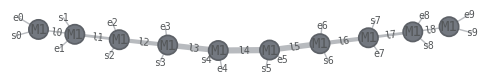

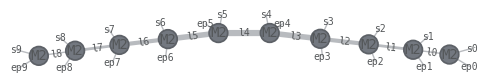

In [ ]:
M1 = read_data("M1_a2_N10")
M2 = read_data("M2_a2_N10")

n = len(M1)
tags = ('M1',)
lpdo_1 = array_to_lpdo(M1, tags)
lpdo_1.draw(show_inds='all')

tags = ('M2',)
lpdo_2 = array_to_lpdo(M2, tags)
lpdo_2 = lpdo_2.H
for i in range (n):
    lpdo_2 = lpdo_2.reindex({f'e{i}':f'ep{i}'})
lpdo_2.draw(show_inds='all')

lpdo_1_acl = add_ancilla(lpdo_1,"a")
lpdo_2_acl = add_ancilla(lpdo_2,"ap")

In [9]:
def lpdo_to_dense_matrix(lpdo):
    # Get the number of sites
    L = len(lpdo.tensors)
    
    # Identify all physical indices
    ket_indices = [f's{i}' for i in range(L)]
    bra_indices = [f'e{i}' for i in range(L)]
    output_inds = ket_indices + bra_indices  # Order: k0, k1, ..., k{L-1}, l0, l1, ..., l{L-1}
    
    # Contract the LPDO, keeping physical indices open
    dense_tensor = lpdo.contract(all, output_inds=output_inds)
    
    # Get the physical dimension (assumed same for all sites)
    d = lpdo.tensors[0].shape[lpdo.tensors[0].inds.index('s0')]  # e.g., 2 for qubits
    
    # Reshape the tensor into a (d^L, d^L) matrix
    dense_matrix = dense_tensor.data.reshape(d**L, d**L)
    
    return np.matrix(dense_matrix)

def lpdo_to_dense_matrix_conj(lpdo):
    # Get the number of sites
    L = len(lpdo.tensors)
    
    # Identify all physical indices
    ket_indices = [f's{i}' for i in range(L)]
    bra_indices = [f'ep{i}' for i in range(L)]
    output_inds = ket_indices + bra_indices  # Order: k0, k1, ..., k{L-1}, l0, l1, ..., l{L-1}
    
    # Contract the LPDO, keeping physical indices open
    dense_tensor = lpdo.contract(all, output_inds=output_inds)
    
    # Get the physical dimension (assumed same for all sites)
    d = lpdo.tensors[0].shape[lpdo.tensors[0].inds.index('s0')]  # e.g., 2 for qubits
    
    # Reshape the tensor into a (d^L, d^L) matrix
    dense_matrix = dense_tensor.data.reshape(d**L, d**L)
    
    return np.matrix(dense_matrix)


def compute_fidelity_dense(rho1, rho2):
    rho1 = (rho1 + rho1.H)/2
    rho2 = (rho2 + rho2.H)/2
    sqrt_rho1 = sqrtm(rho1)
    sqrt_rho2 = sqrtm(rho2)
    product = sqrt_rho1 @ sqrt_rho2
    
    # Compute singular values of the product
    singular_values = np.linalg.svd(product, compute_uv=False)
    
    # Sum the singular values to get the fidelity
    fidelity = np.sum(np.abs(singular_values))  # Use abs to handle small negative values
    
    # Ensure real output (fidelity should be real for Hermitian inputs)
    fidelity = np.real(fidelity)
    return fidelity

def compute_trace_distance_dense(rho1, rho2):
    rho1 = (rho1 + rho1.H)/2
    rho2 = (rho2 + rho2.H)/2
    rhodiff = rho1-rho2
    
    # Compute singular values of the product
    singular_values = np.linalg.svd(rhodiff, compute_uv=False)
    
    # Sum the singular values to get the fidelity
    Td = np.sum(np.abs(singular_values))  # Use abs to handle small negative values
    
    # Ensure real output (fidelity should be real for Hermitian inputs)
    Td = np.real(Td)/2
    return Td

def compute_fidelity_and_trace_dist_dense_from_lpdo(lpdo_1, lpdo_2):
    psi1 = lpdo_to_dense_matrix(lpdo_1)
    rho1 = psi1 @ psi1.H

    psi2 = lpdo_to_dense_matrix_conj(lpdo_2)
    rho2 = (psi2 @ psi2.H).conj()

    F = compute_fidelity_dense(rho1, rho2)
    Td = compute_trace_distance_dense(rho1, rho2)
    return F, Td

In [12]:
F, Td = compute_fidelity_and_trace_dist_dense_from_lpdo(lpdo_1, lpdo_2)
F, Td

(np.float64(0.5597730064792014), np.float64(0.758100408504387))

In [20]:
def brickwall_unitary(psi, n_apply, list_u3, depth, n_Qbit, val_iden = 0,rand = False,start_layer=0,is_acl=0):

    if n_Qbit==0: depth=1
    if n_Qbit==1: depth=1

    for r in range(depth):

        if (r+start_layer)%2==0:
            if is_acl==0:
                for i in range(0, n_Qbit, 2):
                    # print("U_e", i, i + 1, n_apply)

                    if rand == True:
                        G = qu.rand_uni(4, dtype=complex)
                        #G = qu.fsimg(1,1,1,1,1, dtype=complex)
                    else:
                        G = qu.identity(4,dtype=complex)+qu.rand_uni(4, dtype=complex)*val_iden
                
                    psi.gate_(G, (i, i + 1), tags={'U',f'G{n_apply}', f'L{i}D{r}'})
                    list_u3.append(f'G{n_apply}')
                    n_apply+=1

            elif is_acl==1:
                for i in range(0, n_Qbit, 4):

                    if rand == True:
                        G = qu.rand_uni(16, dtype=complex)
                    else:
                        G = qu.identity(16,dtype=complex)+qu.rand_uni(16, dtype=complex)*val_iden
                
                    psi.gate_(G, (i, i + 1,i+2,i+3), tags={'U',f'G{n_apply}', f'L{i}D{r}'})
                    list_u3.append(f'G{n_apply}')
                    n_apply+=1

        else:
            if is_acl==0:
                for i in range(0, n_Qbit-2, 2):
                    # print("U_o", i+1, i + 2, n_apply)
            
                    if rand == True:
                        G = qu.rand_uni(4, dtype=complex)
                        #G = qu.fsimg(1,1,1,1,1, dtype=complex)
                    else:
                        G = qu.identity(4,dtype=complex)+qu.rand_uni(4, dtype=complex)*val_iden

                    psi.gate_(G, (i+1, i + 2), tags={'U',f'G{n_apply}', f'L{i}D{r}'})
                    list_u3.append(f'G{n_apply}')
                    n_apply+=1

            elif is_acl == 1:
                for i in range(2, n_Qbit-2, 4):
                    # print("U_o", i, i + 1,i+2,i+3, n_apply)
            
                    if rand == True:
                        G = qu.rand_uni(16, dtype=complex)
                        #G = qu.fsimg(1,1,1,1,1, dtype=complex)
                    else:
                        G = qu.identity(16,dtype=complex)+qu.rand_uni(16, dtype=complex)*val_iden

                    psi.gate_(G, (i, i + 1,i+2,i+3), tags={'U',f'G{n_apply}', f'L{i}D{r}'})
                    list_u3.append(f'G{n_apply}')
                    n_apply+=1

    return n_apply, list_u3


def staircase_unitary(psi, n_apply, list_u3, depth, n_Qbit, val_iden = 0,rand = False,start_layer=0, is_acl=0):

    if n_Qbit==0: depth=1
    if n_Qbit==1: depth=1

    for r in range(depth):

        if (r+start_layer)%2==0:
            if is_acl == 0:
                for i in range(0, n_Qbit-1, 1):
                    # print("U_e", i, i + 1, n_apply)

                    if rand == True:
                        G = qu.rand_uni(4, dtype=complex)
                        #G = qu.fsimg(1,1,1,1,1, dtype=complex)
                    else:
                        G = qu.identity(4,dtype=complex)+qu.rand_uni(4, dtype=complex)*val_iden
                
                    psi.gate_(G, (i, i + 1), tags={'U',f'G{n_apply}',f'L{i}D{r}'})
                    list_u3.append(f'G{n_apply}')
                    n_apply+=1

            elif is_acl == 1:
                # acts on four sites, two system, two ancilla
                for i in range(0, n_Qbit-3, 2):
                    # print("U_e", i, i + 1, n_apply)

                    if rand == True:
                        G = qu.rand_uni(16, dtype=complex)
            
                    else:
                        G = qu.identity(16,dtype=complex)+qu.rand_uni(16, dtype=complex)*val_iden
                
                    psi.gate_(G, (i, i + 1, i+2, i+3), tags={'U',f'G{n_apply}',f'L{i}D{r}'})
                    list_u3.append(f'G{n_apply}')
                    n_apply+=1

        else:
            if is_acl == 0:
                for i in range(n_Qbit-1, 0, -1):
                    # print("U_o", i-1, i, n_apply)
            
                    if rand == True:
                        G = qu.rand_uni(4, dtype=complex)
                        #G = qu.fsimg(1,1,1,1,1, dtype=complex)
                    else:
                        G = qu.identity(4,dtype=complex)+qu.rand_uni(4, dtype=complex)*val_iden

                    psi.gate_(G, (i-1, i), tags={'U',f'G{n_apply}',f'L{i}D{r}'})
                    list_u3.append(f'G{n_apply}')
                    n_apply+=1

            elif is_acl == 1:
                for i in range(n_Qbit-1, 2, -2):
                    # print("U_o", i-1, i, n_apply)
            
                    if rand == True:
                        G = qu.rand_uni(16, dtype=complex)
                        #G = qu.fsimg(1,1,1,1,1, dtype=complex)
                    else:
                        G = qu.identity(16,dtype=complex)+qu.rand_uni(16, dtype=complex)*val_iden

                    psi.gate_(G, (i-3, i-2, i-1, i), tags={'U',f'G{n_apply}',f'L{i}D{r}'})
                    list_u3.append(f'G{n_apply}')
                    n_apply+=1

    return n_apply, list_u3


def qmps_f(L=16, in_depth=2, val_iden = 0, rand = True,start_layer = 0, framework='brickwall', is_acl=0):

    list_u3=[]
    n_apply=0
    psi = qtn.MPS_computational_state('0' * (L))
    for i in range(L):
        t = psi[i]
        indx = 'k'+str(i)
        t.modify(left_inds=[indx])

    for t in range(L):
        psi[t].modify(tags=[f"I{t}", "MPS"])

    if framework == 'brickwall':
        n_apply, list_u3=brickwall_unitary(psi, n_apply, list_u3, in_depth, L, val_iden = val_iden, rand =rand,start_layer=start_layer,is_acl=is_acl)
    elif framework == 'staircase':
        n_apply, list_u3=staircase_unitary(psi, n_apply, list_u3, in_depth, L, val_iden = val_iden, rand =rand,start_layer=start_layer,is_acl=is_acl)
    elif framework == 'mixed':
        n_apply, list_u3=brickwall_unitary(psi, n_apply, list_u3, in_depth, L, val_iden = val_iden, rand =rand,start_layer=start_layer,is_acl=is_acl)
        n_apply, list_u3=staircase_unitary(psi, n_apply, list_u3, in_depth, L, val_iden = val_iden, rand =rand,start_layer=start_layer,is_acl=is_acl)


    return psi.astype_('complex128')#, list_u3


def extract_unitary_circuit(psi_pqc, num_qubits):
    # only system qubits

    pqc = psi_pqc.tensors[num_qubits]
    for i in range (num_qubits+1,len(psi_pqc.tensors)):
        pqc = pqc&psi_pqc.tensors[i] #extrating the circuit part

    for i in range (num_qubits):
        pqc = pqc.reindex({f'k{i}':f's{i}'})
        pqc = pqc.reindex({psi_pqc.tensors[i].inds[-1]:f'sp{i}'})

    return pqc


def extract_unitary_circuit_acl(psi_pqc, num_qubits):
    # for ancilla. num_qubits = 2*n

    pqc = psi_pqc.tensors[num_qubits]
    for i in range (num_qubits+1,len(psi_pqc.tensors)):
        pqc = pqc&psi_pqc.tensors[i] #extrating the circuit part

    for i in range (num_qubits):
        if (i%2):
            pqc = pqc.reindex({f'k{i}':f's{i//2}'})
            pqc = pqc.reindex({psi_pqc.tensors[i].inds[-1]:f'sp{i//2}'})
        else:
            pqc = pqc.reindex({f'k{i}':f'a{i//2}'})
            pqc = pqc.reindex({psi_pqc.tensors[i].inds[-1]:f'ap{i//2}'})

    return pqc

In [21]:
def get_pqc_torch(n, depth, framework, is_acl, rand=True, val_iden=0.0):

    if is_acl == 0:
        num_qubits = n # physical 
        psi_pqc = qmps_f(num_qubits, in_depth= depth, val_iden = val_iden,rand = rand, framework=framework)
        pqc = extract_unitary_circuit(psi_pqc, num_qubits)
        # full_contraction(pqc, lpdo_1, lpdo_2, is_show=0)


    elif is_acl == 1:
        num_qubits = 2 * n # physical + ancilla 
        psi_pqc = qmps_f(num_qubits, in_depth= depth, val_iden = val_iden, rand = rand, framework=framework,is_acl=1)
        pqc = extract_unitary_circuit_acl(psi_pqc, num_qubits)
        # full_contraction(pqc, lpdo_1_acl, lpdo_2_acl, is_show=0)

    return pqc


def get_lpdo_torch(M1, M2, is_acl):

    n = len(M1)
    lpdo_1 = array_to_lpdo(M1, ('M1',))
    lpdo_2 = array_to_lpdo(M2, ('M2',))

    lpdo_1_acl = add_ancilla(lpdo_1,"a")
    lpdo_2_acl = add_ancilla(lpdo_2,"a")

    if is_acl == 0:
        lpdo_1_torch = lpdo_1.copy()
        lpdo_2_torch = lpdo_2.copy()
    elif is_acl == 1:
        lpdo_1_torch = lpdo_1_acl.copy()
        lpdo_2_torch = lpdo_2_acl.copy()

    return lpdo_1_torch, lpdo_2_torch

def full_contraction(pqc, lpdo_1, lpdo_2, lpdo_1_conj, lpdo_2_conj, is_show=0):
    if is_show == 1:
        (lpdo_1_conj & lpdo_1 & pqc).draw(['U','M2','M1'])

    ov1 = (lpdo_1_conj & lpdo_1 & pqc).contract(optimize=opti)
    ov2 = (lpdo_2_conj & lpdo_2 & pqc).contract(optimize=opti)
    
    dist = (1/2)*(torch.abs(ov1-ov2))
    return -dist

In [22]:
class TNModel(torch.nn.Module):
    # this class is inheritance of torch.nn.Module

    def __init__(self, pqc, lpdo_1, lpdo_2, is_acl):
        super().__init__()

        pqc_torch = pqc.copy()
        pqc_torch.apply_to_arrays(lambda x: torch.tensor(x, dtype=torch.complex128))
        # extract the raw arrays and a skeleton of the TN
        params, self.skeleton = qtn.pack(pqc_torch)
        # n.b. you might want to do extra processing here to e.g. store each
        # parameter as a reshaped matrix (from left_inds -> right_inds), for
        # some optimizers, and for some torch parametrizations

        lpdo_1_conj = lpdo_1.H
        lpdo_2_conj = lpdo_2.H

        if is_acl == 0:
            for i in range(n):
                lpdo_1_conj = lpdo_1_conj.reindex({f's{i}':f'sp{i}'})
                lpdo_2_conj = lpdo_2_conj.reindex({f's{i}':f'sp{i}'})

        elif is_acl == 1:
            for i in range(n):
                lpdo_1_conj = lpdo_1_conj.reindex({f's{i}':f'sp{i}'})
                lpdo_2_conj = lpdo_2_conj.reindex({f's{i}':f'sp{i}'})
                lpdo_1_conj = lpdo_1_conj.reindex({f'a{i}':f'ap{i}'})
                lpdo_2_conj = lpdo_2_conj.reindex({f'a{i}':f'ap{i}'})
                    

        lpdo_1_torch = lpdo_1.copy()
        lpdo_2_torch = lpdo_2.copy()
        lpdo_1_torch.apply_to_arrays(lambda x: torch.tensor(x, dtype=torch.complex128))
        lpdo_2_torch.apply_to_arrays(lambda x: torch.tensor(x, dtype=torch.complex128))
        lpdo_1_conj.apply_to_arrays(lambda x: torch.tensor(x, dtype=torch.complex128))
        lpdo_2_conj.apply_to_arrays(lambda x: torch.tensor(x, dtype=torch.complex128))

        self.torch_params = torch.nn.ParameterDict({
            # "str(i)" is key conversion: torch requires strings as keys
            str(i): torch.nn.Parameter(initial)
            for i, initial in params.items()
        })
        self._loss_fn = lambda x: full_contraction(x, lpdo_1_torch, lpdo_2_torch, lpdo_1_conj, lpdo_2_conj)
        
    def forward(self):
        # convert back to original int key format
        params = {int(i): p for i, p in self.torch_params.items()}
        # reconstruct the TN with the new parameters
        pqc = qtn.unpack(params, self.skeleton)
        
        # isometrize and then return the energy
        return self._loss_fn(pqc.isometrize(method='exp'))
    
    def get_unitary_circuit(self):
        """Extract the optimized unitary quantum circuit."""
        # Convert parameters back to int keys
        params = {int(i): p for i, p in self.torch_params.items()}
        # Reconstruct the circuit
        pqc = qtn.unpack(params, self.skeleton)
        # Apply isometrization to get unitary gates
        return pqc.isometrize(method='exp')

In [ ]:
M1 = read_data("M1_a2_N10")
M2 = read_data("M2_a2_N10")
n = len(M1)
is_acl = 1
depth = 2  # this should be twice the depth in the note
framework = 'staircase'
rand = True
val_iden = 0.0

pqc_init = get_pqc_torch(n, depth, framework, is_acl, rand=rand, val_iden=val_iden)
lpdo_1_torch, lpdo_2_torch = get_lpdo_torch(M1, M2, is_acl);
pqc_torch = pqc_init.copy()

['arr_1', 'arr_2', 'arr_3', 'arr_4', 'arr_5', 'arr_6']
['arr_1', 'arr_2', 'arr_3', 'arr_4', 'arr_5', 'arr_6']


In [44]:
model = TNModel(pqc_torch, lpdo_1_torch, lpdo_2_torch, is_acl)
print("Model created! Initial loss:", model.forward().item())

Model created! Initial loss: -0.0011017288023205379


In [45]:
lr = 0.01
optimizer = optim.Adamax(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer,step_size=200, gamma=0.5)
num_steps = 1000
pbar = tqdm.tqdm(range(num_steps))
previous_loss = torch.inf
losses = []

print("Initial loss:", model.forward().item())

for step in pbar:
    optimizer.zero_grad()
    loss = model.forward()
    losses.append(loss.detach().numpy())
    loss.backward()
    optimizer.step()
    pbar.set_description(f"Loss={loss} - LR={lr}")
    if step > 100 and torch.abs(previous_loss - loss) < 1e-10:
        print("Early stopping loss difference is smaller than 1e-10")
        break
    previous_loss = loss.clone()
    
print(f'trainng loss: {loss}')

Loss=-0.12472821697125279 - LR=0.01:   0%|          | 2/1000 [00:00<00:54, 18.39it/s]

Initial loss: -0.0011017288023205379


Loss=-0.7132685917232218 - LR=0.01:  99%|█████████▉| 991/1000 [00:37<00:00, 26.46it/s]

Early stopping loss difference is smaller than 1e-10
trainng loss: -0.7132685917232218
